In [3]:
# env: behav_fit (for arviz --> posterior traces)
import pandas as pd
import os.path as op
import os
import pandas as pd
from os import listdir
import numpy as np

bids_folder_local = '/Users/mrenke/data/ds-stressrisk'
bids_folder_ex = '/Volumes/mrenkeED/data/ds-stressrisk'

bids_folder = bids_folder_ex
subFolders = [f for f in listdir(bids_folder) if f[0:3] == 'sub']

# 1. get value-estimates from traces (model-eu or NLC) and add to df(general)
# 1.1 .....
# 1.2 check correlations (between models and values)

# 2. create event files for SPMs

In [4]:
# 1. EU and Vhat(NLC) estimates

import arviz as az

idata_EU = az.from_netcdf('/Users/mrenke/data/ds-stressrisk/derivatives/cogmodels/model-EU_1_trace.netcdf')
eu1_df = idata_EU.posterior['eu1'].to_dataframe().groupby('eu1_dim_0').mean() # average over trials
eu2_df = idata_EU.posterior['eu2'].to_dataframe().groupby('eu2_dim_0').mean() # average over trials

idata_NLC = az.from_netcdf('/Users/mrenke/data/ds-stressrisk/derivatives/cogmodels/model-NLC_1_trace.netcdf')

n1h_df = idata_NLC.posterior['n1_hat'].to_dataframe().groupby('n1_hat_dim_0').mean() # average over trials
n2h_df = idata_NLC.posterior['n2_hat'].to_dataframe().groupby('n2_hat_dim_0').mean() # average over trials

In [5]:
# add those estimates to general df

from stress_risk.behavior.utils import get_data

df = get_data(bids_folder_local)
df = df.reset_index()
df = df.set_index(['subject','session','trial_nr'])
#df = df.set_index('session',append=True)
df['EU1'] = eu1_df.values
df['EU2'] = eu2_df.values

df['EV1'] = df['prob1'] * df['n1']
df['EV2'] = df['prob2'] * df['n2']

df['Vhat1'] = df['prob1'] * np.exp(n1h_df.values.flatten()) # changed here to exp. 
df['Vhat2'] = df['prob2'] * np.exp(n2h_df.values.flatten())

/Users/mrenke/mambaforge/envs/behav_fit2/lib/python3.10/site-packages/nilearn/glm/__init__.py:55: FutureWarning: The nilearn.glm module is experimental. It may change in any future release of Nilearn.
  warn('The nilearn.glm module is experimental. '
/Users/mrenke/mambaforge/envs/behav_fit2/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# add difference-Values of chosen-unchosen

def get_diff_of_chosen(d, v):  
    n1 = f'{v}1'
    n2 = f'{v}2'
    if d['chose_risky'] == True:
        if d['prob1'] == 0.55:
            diff = d[n1] - d[n2]
        elif d['prob2'] == 0.55:
            diff = d[n2] - d[n1]
    elif d['chose_risky'] == False:
        if d['prob1'] == 1:
            diff = d[n1] - d[n2]
        elif d['prob2'] == 1.:
            diff = d[n2] - d[n1]
    return diff

df['EU-diff'] = df.apply(get_diff_of_chosen, args=('EU',), axis=1) # comma in args=(xx,) lets interpreter know it is a tulpe
df['EV-diff'] = df.apply(get_diff_of_chosen, args=('EV',), axis=1)
df['Vhat-diff'] = df.apply(get_diff_of_chosen, args=('Vhat',), axis=1)
df_general = df

In [7]:
df

run        rt    n1    n2  prob1  prob2  choice  \
subject session trial_nr                                                    
1       1       1           1  0.476974  13.0  10.0   0.55    1.0    True   
                2           1  0.505059   8.0   7.0   0.55    1.0    True   
                3           1  0.609260  13.0   7.0   0.55    1.0   False   
                4           1  0.522144  38.0  28.0   0.55    1.0    True   
                5           1  0.608297  16.0  10.0   0.55    1.0   False   
...                       ...       ...   ...   ...    ...    ...     ...   
61      2       116         6  1.189453  39.0  14.0   0.55    1.0   False   
                117         6  0.755411  43.0  20.0   0.55    1.0   False   
                118         6  0.905503  34.0  14.0   0.55    1.0    True   
                119         6  1.873285  34.0  20.0   0.55    1.0    True   
                120         6  0.989251  42.0  28.0   0.55    1.0    True   

                          risky_first  chose_risky  n_risky  ...  group  \
subject session trial_nr                                     ...          
1       1       1                True        False     13.0  ...    0.0   
                2                True        False      8.0  ...    0.0   
                3                True         True     13.0  ...    0.0   
                4                True        False     38.0  ...    0.0   
                5                True         True     16.0  ...    0.0   
...                               ...          ...      ...  ...    ...   
61      2       116              True         True     39.0  ...    0.0   
                117              True         True     43.0  ...    0.0   
                118              True        False     34.0  ...    0.0   
                119              True        False     34.0  ...    0.0   
                120              True        False     42.0  ...    0.0   

                                EU1        EU2    EV1   EV2      Vhat1  \
subject session trial_nr                                                 
1       1       1          6.362533   9.000968   7.15  10.0   9.523860   
                2          3.999485   6.400550   4.40   7.0   6.841144   
                3          6.362533   6.400550   7.15   7.0   9.523860   
                4         17.770150  24.112863  20.90  28.0  19.781348   
                5          7.760909   9.000968   8.80  10.0  10.971426   
...                             ...        ...    ...   ...        ...   
61      2       116       20.756026  13.638273  21.45  14.0  19.694265   
                117       22.872536  19.433504  23.65  20.0  21.417760   
                118       18.109227  13.638273  18.70  14.0  17.504210   
                119       18.109227  19.433504  18.70  20.0  17.504210   
                120       22.343478  27.147218  23.10  28.0  20.989086   

                              Vhat2   EU-diff  EV-diff  Vhat-diff  
subject session trial_nr                                           
1       1       1         10.189897  2.638435     2.85   0.666038  
                2          7.347297  2.401065     2.60   0.506153  
                3          7.347297 -0.038017     0.15   2.176563  
                4         26.194217  6.342712     7.10   6.412869  
                5         10.189897 -1.240059    -1.20   0.781529  
...                             ...       ...      ...        ...  
61      2       116       13.525942  7.117753     7.45   6.168323  
                117       18.957498  3.439032     3.65   2.460262  
                118       13.525942 -4.470954    -4.70  -3.978268  
                119       18.957498  1.324277     1.30   1.453289  
                120       26.066941  4.803740     4.90   5.077855  

[11891 rows x 27 columns]

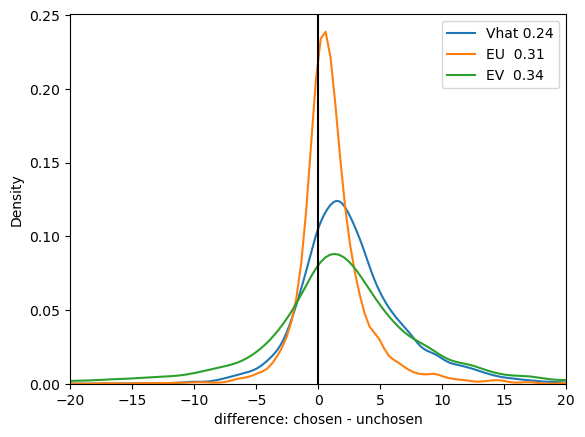

In [57]:
# loook a distribution of value-Differences
import seaborn as sns
import matplotlib.pyplot as plt

#sub = 21
d = df#.loc[sub]
sns.kdeplot(d['Vhat-diff'], label=f'Vhat {(d["Vhat-diff"]<0.0).mean():0.2f}')
sns.kdeplot(d['EU-diff'], label=f'EU  {(d["EU-diff"]<0.0).mean():0.2f}')
sns.kdeplot(d['EV-diff'], label = f'EV  {(d["EV-diff"]<0.0).mean():0.2f}')
plt.axvline(0,c='k')
plt.xlim(-20,20)
plt.xlabel('difference: chosen - unchosen')
#plt.title(f'subject {sub}')
plt.legend()



/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_34236/1300941561.py:4: FutureWarning: In a future version of pandas all arguments of MultiIndex.set_names except for the argument 'names' will be keyword-only.
  r.index = r.index.set_names('variable1', -1)
/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_34236/1300941561.py:8: FutureWarning: In a future version of pandas all arguments of MultiIndex.set_names except for the argument 'names' will be keyword-only.
  r.index = r.index.set_names('variable2', -1)


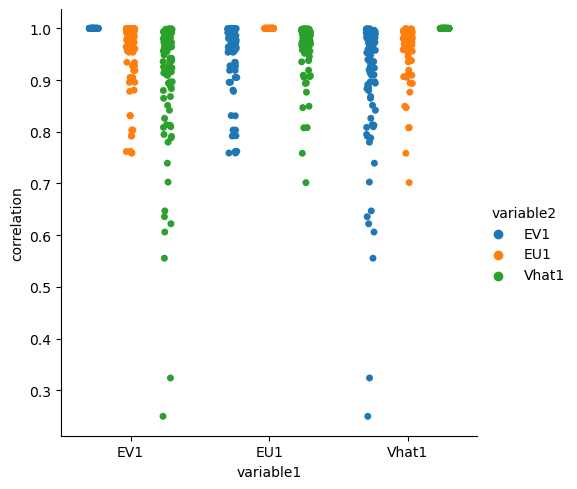

In [37]:
# check correlation, one value, between EV-EU-Vhat
reg_n = '1'

r = df[[f'EV{reg_n}', f'EU{reg_n}',  f'Vhat{reg_n}']].groupby(['subject', 'session']).apply(lambda d: d.corr())
r.index = r.index.set_names('variable1', -1)
r.groupby('variable1').mean()
r = r.stack().to_frame('correlation')

r.index = r.index.set_names('variable2', -1)

sns.catplot(r.reset_index(), x='variable1', y='correlation', hue='variable2', dodge=True)

/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_26933/236276633.py:6: FutureWarning: In a future version of pandas all arguments of MultiIndex.set_names except for the argument 'names' will be keyword-only.
  r.index = r.index.set_names('variable1', -1)
/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_26933/236276633.py:10: FutureWarning: In a future version of pandas all arguments of MultiIndex.set_names except for the argument 'names' will be keyword-only.
  r.index = r.index.set_names('variable2', -1)


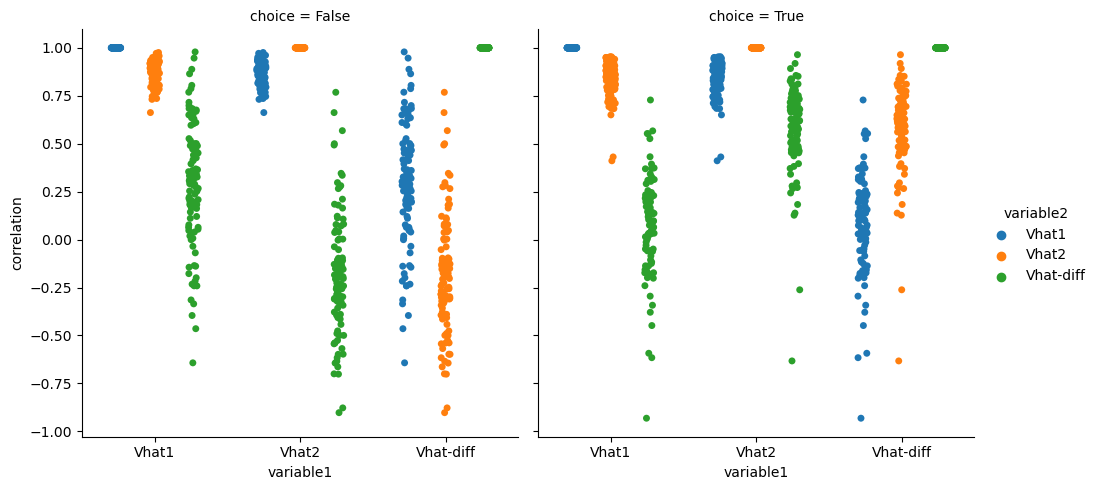

In [9]:
# check correlations, one model, between values (v1,v2,v-diff)
import seaborn as sns

model_n = 'Vhat'
r = df[[f'{model_n}1', f'{model_n}2', f'{model_n}-diff', 'choice']].groupby(['subject', 'session', 'choice']).apply(lambda d: d.corr())
r.index = r.index.set_names('variable1', -1)
r.groupby('variable1').mean()
r = r.stack().to_frame('correlation')

r.index = r.index.set_names('variable2', -1)

sns.catplot(r.reset_index(), x='variable1', y='correlation',col='choice', hue='variable2', dodge=True)

/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_26933/2759612575.py:6: FutureWarning: In a future version of pandas all arguments of MultiIndex.set_names except for the argument 'names' will be keyword-only.
  r.index = r.index.set_names('variable1', -1)
/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_26933/2759612575.py:10: FutureWarning: In a future version of pandas all arguments of MultiIndex.set_names except for the argument 'names' will be keyword-only.
  r.index = r.index.set_names('variable2', -1)


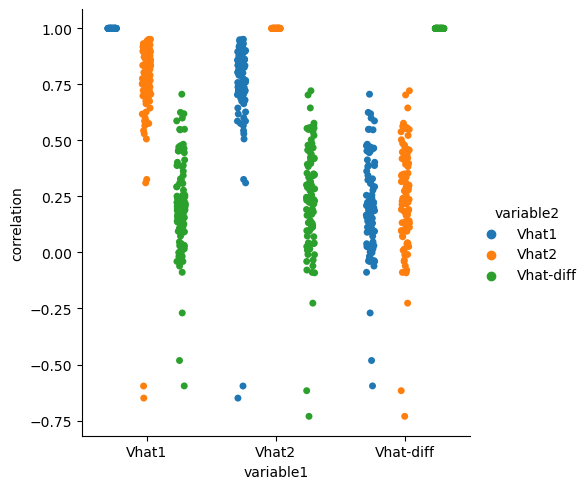

In [10]:
# check correlations, one model, between values (v1,v2,v-diff)
import seaborn as sns

model_n = 'Vhat'
r = df[[f'{model_n}1', f'{model_n}2', f'{model_n}-diff']].groupby(['subject', 'session']).apply(lambda d: d.corr())
r.index = r.index.set_names('variable1', -1)
r.groupby('variable1').mean()
r = r.stack().to_frame('correlation')

r.index = r.index.set_names('variable2', -1)

sns.catplot(r.reset_index(), x='variable1', y='correlation', hue='variable2', dodge=True)

In [9]:
# model-1
# needs df_timings(of each sub,ses,run) & general_df from above

model = 'EV'
specification = f'_{model}-1'

missed_choices = []
eu_choice_diffs_all = []
eu2_all = []

for sub in subFolders:
    target_folder = op.join(bids_folder_ex,'derivatives','spm',sub) #,f'ses-{ses}')       
    if not op.exists(target_folder):
        os.mkdir(target_folder)

    for ses in [1,2]:
        target_folder = op.join(bids_folder_ex,'derivatives','spm',sub,f'ses-{ses}', 'event_files')
        
        if not op.exists(target_folder):
            os.mkdir(target_folder)

        for run in range(1,7):
            df_timings = pd.read_table(op.join(bids_folder_local, sub,f'ses-{ses}','func', f'{sub}_ses-{ses}_task-risk_run-{run}_events.tsv'))
            onsets_eu1 =[]
            eu1s = []
            durations_eu1 = []
            onsets_eu2 =[]
            eu2s =[]
            eu_choice_diffs  = []
            onsets_eu_choice_diff = []

            for row in df_timings.iterrows():
                try:
                    if row[1]['trial_type'] == 'stimulus 1':
                        eu1 =  df.loc[(int(sub[4:6]), ses, row[1]['trial_nr'])][f'{model}1']  #row[1]['n1'] * row[1]['prob1']
                        eu1s.append(eu1)
                        onsets_eu1.append(row[1]['onset'])
                        durations_eu1.append(0.6)

                    elif row[1]['trial_type'] == 'stimulus 2':
                        eu2 =     df.loc[(int(sub[4:6]), ses, row[1]['trial_nr'])][f'{model}2']  #row[1]['n1'] * row[1]['prob1']
                        eu2s.append(eu2) # this was wrong before
                        onsets_eu2.append(row[1]['onset'])


                    elif row[1]['trial_type'] == 'choice':
                        if row[1]['choice'] == 1:
                            eu_choice_diffs.append(eu1-eu2)
                        elif row[1]['choice'] == 2:
                            eu_choice_diffs.append(eu2-eu1)
                        onsets_eu_choice_diff.append(row[1]['onset'])
                except:
                    t_n = row[1]['trial_nr']
                    missed_choices.append(f'{sub} in ses {ses} missing choice for trial {t_n} ')

            durations_eu2   =    durations_eu1
               
            onsets_s2_fil = onsets_eu2 # onsets are here automatically filtered for trials with choice, different to EV-model
            durations_diff = (np.array(onsets_eu_choice_diff) - np.array(onsets_s2_fil)).tolist() 
            onsets_diff = onsets_s2_fil # 

            stim1 =pd.DataFrame(data= {'onset':onsets_eu1, 'duration':durations_eu1,'strength':eu1s})
            fn = op.join(target_folder, f'{sub}_ses-{ses}_task-risk_run-{run}_events_n1{specification}.txt')
            stim1.to_csv(fn, sep ='\t',index=False,header=False)

            stim2 =pd.DataFrame(data= {'onset':onsets_eu2, 'duration':durations_eu2,'strength':eu2s})
            fn = op.join(target_folder, f'{sub}_ses-{ses}_task-risk_run-{run}_events_n2{specification}.txt')
            stim2.to_csv(fn, sep ='\t',index=False,header=False)

            ev_diff= pd.DataFrame(data= {'onset':onsets_diff, 'duration':durations_diff,'strength':eu_choice_diffs})
            fn = op.join(target_folder, f'{sub}_ses-{ses}_task-risk_run-{run}_events_diff{specification}.txt')
            ev_diff.to_csv(fn, sep ='\t',index=False,header=False)


                       

In [7]:
# model-2 & -3 --> diff regressors for chosen & unchosen
# needs df_timings(of each sub,ses,run) & general_df from above

model = 'EV' # 'EU', 'Vhat'
specification = f'_{model}-2'# '_NLC-2'

missed_choices = []

for sub in subFolders:
    target_folder = op.join(bids_folder_ex,'derivatives','spm',sub) #,f'ses-{ses}')       
    if not op.exists(target_folder):
        os.mkdir(target_folder)

    for ses in [1,2]:
        target_folder = op.join(bids_folder_ex,'derivatives','spm',sub,f'ses-{ses}', 'event_files')
        
        if not op.exists(target_folder):
            os.mkdir(target_folder)

        for run in range(1,7):
            df_timings = pd.read_table(op.join(bids_folder_local, sub,f'ses-{ses}','func', f'{sub}_ses-{ses}_task-risk_run-{run}_events.tsv'))
            
            
            onsets_v1_chosen =[]
            v1s_chosen = []
            v1s_unchosen = []
            onsets_v1_unchosen =[]
            v1chosen_diffs  = []

            onsets_v2_chosen =[]
            v2s_chosen = []
            onsets_v2_unchosen =[]
            v2s_unchosen = []
            v2chosen_diffs  = []

            dur_v1s_chosen = []
            dur_v1s_unchosen = [] 

            dur_v2s_chosen = []
            dur_v2s_unchosen = [] 

            for row in df_timings.iterrows():
                try:
                    if row[1]['trial_type'] == 'stimulus 1':
                        eu1 =  df.loc[(int(sub[4:6]), ses, row[1]['trial_nr'])][f'{model}1']  #row[1]['n1'] * row[1]['prob1']
                        onset_eu1 = (row[1]['onset'])

                    elif row[1]['trial_type'] == 'stimulus 2':
                        eu2 =     df.loc[(int(sub[4:6]), ses, row[1]['trial_nr'])][f'{model}2']  #row[1]['n1'] * row[1]['prob1']
                        onset_eu2 = row[1]['onset']

                    elif row[1]['trial_type'] == 'choice':
                        onset_choice =  row[1]['onset']

                        if row[1]['choice'] == 1:
                            v1s_chosen.append(eu1)
                            v1chosen_diffs.append(eu1-eu2)
                            onsets_v1_chosen.append(onset_eu1)
                            dur_v1s_chosen.append(0.6)

                            v2s_unchosen.append(eu2)
                            onsets_v2_unchosen.append(onset_eu2)
                            dur_v2s_unchosen.append(onset_choice - onset_eu2)

                        elif row[1]['choice'] == 2:
                            v2s_chosen.append(eu2)
                            v2chosen_diffs.append(eu2-eu1)
                            onsets_v2_chosen.append(onset_eu2)
                            dur_v2s_chosen.append(onset_choice - onset_eu2)

                            v1s_unchosen.append(eu1)
                            onsets_v1_unchosen.append(onset_eu1)
                            dur_v1s_unchosen.append(0.6)

                except:
                    t_n = row[1]['trial_nr']
                    missed_choices.append(f'{sub} in ses {ses} missing choice for trial {t_n} ')


            v1_ch =pd.DataFrame(data= {'onset':onsets_v1_chosen, 'duration':dur_v1s_chosen,'value':v1s_chosen, 'diff':v1chosen_diffs})
            fn = op.join(target_folder, f'{sub}_ses-{ses}_task-risk_run-{run}_events_v1-chosen{specification}.txt')
            v1_ch.to_csv(fn, sep ='\t',index=False,header=False)

            v2_ch =pd.DataFrame(data= {'onset':onsets_v2_chosen, 'duration':dur_v2s_chosen,'value':v2s_chosen, 'diff':v2chosen_diffs})
            fn = op.join(target_folder, f'{sub}_ses-{ses}_task-risk_run-{run}_events_v2-chosen{specification}.txt')
            v2_ch.to_csv(fn, sep ='\t',index=False,header=False)

            v1_unch =pd.DataFrame(data= {'onset':onsets_v1_unchosen, 'duration':dur_v1s_unchosen,'value':v1s_unchosen})
            fn = op.join(target_folder, f'{sub}_ses-{ses}_task-risk_run-{run}_events_v1-unchosen{specification}.txt')
            v1_unch.to_csv(fn, sep ='\t',index=False,header=False)

            v2_unch =pd.DataFrame(data= {'onset':onsets_v2_unchosen, 'duration':dur_v2s_unchosen,'value':v2s_unchosen})
            fn = op.join(target_folder, f'{sub}_ses-{ses}_task-risk_run-{run}_events_v2-unchosen{specification}.txt')
            v2_unch.to_csv(fn, sep ='\t',index=False,header=False)

            


len(missed_choices)
                       

218

In [23]:
# risky & safe 

model = 'NLC' # 'EU', 'Vhat'
model_n = 'Vhat'

specification = f'_{model}-4'# ri-sa-fi-se, risky safe first second

missed_choices = []

for sub in subFolders:
    target_folder = op.join(bids_folder_ex,'derivatives','spm',sub) #,f'ses-{ses}')       
    if not op.exists(target_folder):
        os.mkdir(target_folder)

    for ses in [1,2]:
        target_folder = op.join(bids_folder_ex,'derivatives','spm',sub,f'ses-{ses}', 'event_files')
        
        if not op.exists(target_folder):
            os.mkdir(target_folder)


        for run in range(1,7):
            df_timings = pd.read_table(op.join(bids_folder_local, sub,f'ses-{ses}','func', f'{sub}_ses-{ses}_task-risk_run-{run}_events.tsv'))
            
            onsets_risky_first =[]
            value_risky_first = []

            onsets_risky_second =[]
            value_risky_second = []

            onsets_safe_first =[]
            value_safe_first = []

            onsets_safe_second =[]
            value_safe_second = []

            for row in df_timings.iterrows():
                try:
                    if row[1]['trial_type'] == 'stimulus 1':
                        if row[1]['prob1'] == 0.55:
                            value_risky_first.append(df.loc[(int(sub[4:6]), ses, row[1]['trial_nr'])][f'{model_n}1'])
                            onsets_risky_first.append(row[1]['onset'])
                        elif row[1]['prob1'] == 1:
                            value_safe_first.append(df.loc[(int(sub[4:6]), ses, row[1]['trial_nr'])][f'{model_n}1'])
                            onsets_safe_first.append(row[1]['onset'])    

                    elif row[1]['trial_type'] == 'stimulus 2':
                        if row[1]['prob2'] == 0.55:
                            value_risky_second.append(df.loc[(int(sub[4:6]), ses, row[1]['trial_nr'])][f'{model_n}1'])
                            onsets_risky_second.append(row[1]['onset'])
                        elif row[1]['prob2'] == 1:
                            value_safe_second.append(df.loc[(int(sub[4:6]), ses, row[1]['trial_nr'])][f'{model_n}1'])
                            onsets_safe_second.append(row[1]['onset']) 
                except:
                    t_n = row[1]['trial_nr']                    
                    print(f'{sub}, {ses},{run}, {t_n} makes problems')
                    missed_choices.append(f'{sub} in ses {ses} missing choice for trial {t_n} ')

            risky_first =pd.DataFrame(data= {'onset':onsets_risky_first, 'value':value_risky_first})
            fn = op.join(target_folder, f'{sub}_ses-{ses}_task-risk_run-{run}_events_risky-first{specification}.txt')
            risky_first.to_csv(fn, sep ='\t',index=False,header=False)

            risky_second =pd.DataFrame(data= {'onset':onsets_risky_second, 'value':value_risky_second})
            fn = op.join(target_folder, f'{sub}_ses-{ses}_task-risk_run-{run}_events_risky-second{specification}.txt')
            risky_second.to_csv(fn, sep ='\t',index=False,header=False)

            safe_first =pd.DataFrame(data= {'onset':onsets_safe_first, 'value':value_safe_first})
            fn = op.join(target_folder, f'{sub}_ses-{ses}_task-risk_run-{run}_events_safe-first{specification}.txt')
            safe_first.to_csv(fn, sep ='\t',index=False,header=False)

            safe_second =pd.DataFrame(data= {'onset':onsets_safe_second, 'value':value_safe_second})
            fn = op.join(target_folder, f'{sub}_ses-{ses}_task-risk_run-{run}_events_safe-second{specification}.txt')
            safe_second.to_csv(fn, sep ='\t',index=False,header=False)

            #print(f'{sub} done')

len(missed_choices)
                                  

sub-02, 2,6, 116 makes problems
sub-02, 2,6, 116 makes problems
sub-03, 1,5, 98 makes problems
sub-03, 1,5, 98 makes problems
sub-03, 2,6, 117 makes problems
sub-03, 2,6, 117 makes problems
sub-05, 2,2, 36 makes problems
sub-05, 2,2, 36 makes problems
sub-12, 1,1, 12 makes problems
sub-12, 1,1, 12 makes problems
sub-12, 1,2, 40 makes problems
sub-12, 1,2, 40 makes problems
sub-12, 1,3, 60 makes problems
sub-12, 1,3, 60 makes problems
sub-12, 2,2, 35 makes problems
sub-12, 2,2, 35 makes problems
sub-12, 2,2, 38 makes problems
sub-12, 2,2, 38 makes problems
sub-12, 2,3, 56 makes problems
sub-12, 2,3, 56 makes problems
sub-12, 2,4, 62 makes problems
sub-12, 2,4, 62 makes problems
sub-12, 2,4, 64 makes problems
sub-12, 2,4, 64 makes problems
sub-12, 2,4, 65 makes problems
sub-12, 2,4, 65 makes problems
sub-12, 2,4, 66 makes problems
sub-12, 2,4, 66 makes problems
sub-12, 2,4, 67 makes problems
sub-12, 2,4, 67 makes problems
sub-12, 2,4, 68 makes problems
sub-12, 2,4, 68 makes problems
sub-

218

In [27]:

sub = 'sub-61'#subFolders[0]
ses = 2
run=6
df_timings = pd.read_table(op.join(bids_folder_local, sub,f'ses-{ses}','func', f'{sub}_ses-{ses}_task-risk_run-{run}_events.tsv'))
t_n = 115#row[1]['trial_nr']
df.loc[(int(sub[4:6]), ses, t_n)][f'{model_n}1']


KeyError: (61, 2, 115)

In [30]:
# Vhat NLC estimate

specification = '_NLCn'
v_name = 'Vhat'

missed_choices = []
for sub in subFolders:
    target_folder = op.join(bids_folder_ex,'derivatives','spm',sub) #,f'ses-{ses}')       
    if not op.exists(target_folder):
        os.mkdir(target_folder)

    for ses in [1,2]:
        target_folder = op.join(bids_folder_ex,'derivatives','spm',sub,f'ses-{ses}')
        
        if not op.exists(target_folder):
            os.mkdir(target_folder)

        for run in range(1,7):
            df_timings = pd.read_table(op.join(bids_folder_local, sub,f'ses-{ses}','func', f'{sub}_ses-{ses}_task-risk_run-{run}_events.tsv'))
            onsets_v1 =[]
            v1s = []
            durations_v1 = []
            onsets_v2 =[]
            v2s =[]
            v_choice_diffs  = []
            onsets_v_choice_diff = []

            for row in df_timings.iterrows():
                try:
                    if row[1]['trial_type'] == 'stimulus 1':
                        v1 =  df.loc[(int(sub[4:6]), ses, row[1]['trial_nr'])][f'{v_name}1'] 
                        v1s.append(v1)
                        onsets_v1.append(row[1]['onset'])
                        durations_v1.append(0.6)

                    elif row[1]['trial_type'] == 'stimulus 2':
                        v2 =  df.loc[(int(sub[4:6]), ses, row[1]['trial_nr'])][f'{v_name}2']  
                        v2s.append(v2) # this was wrong before
                        onsets_v2.append(row[1]['onset'])


                    elif row[1]['trial_type'] == 'choice':
                        if row[1]['choice'] == 1:
                            v_choice_diffs.append(v1-v2)
                        elif row[1]['choice'] == 2:
                            v_choice_diffs.append(v2-v1)
                        onsets_v_choice_diff.append(row[1]['onset'])
                except:
                    t_n = row[1]['trial_nr']
                    missed_choices.append(f'{sub} in ses {ses} missing choice for trial {t_n} ')

            durations_v2   =    durations_v1
               
            durations_diff = (np.array(onsets_v_choice_diff) - np.array(onsets_v2)).tolist() 
            onsets_diff = onsets_v2 # onsets are here automatically filtered for trials with choice, different to EV-model


            stim1 =pd.DataFrame(data= {'onset':onsets_v1, 'duration':durations_v1,'strength':v1s})
            fn = op.join(target_folder, f'{sub}_ses-{ses}_task-risk_run-{run}_events_n1{specification}.txt')
            stim1.to_csv(fn, sep ='\t',index=False,header=False)

            stim2 =pd.DataFrame(data= {'onset':onsets_v2, 'duration':durations_v2,'strength':v2s})
            fn = op.join(target_folder, f'{sub}_ses-{ses}_task-risk_run-{run}_events_n2{specification}.txt')
            stim2.to_csv(fn, sep ='\t',index=False,header=False)

            v_diff= pd.DataFrame(data= {'onset':onsets_diff, 'duration':durations_diff,'strength':v_choice_diffs})
            fn = op.join(target_folder, f'{sub}_ses-{ses}_task-risk_run-{run}_events_diff{specification}.txt')
            v_diff.to_csv(fn, sep ='\t',index=False,header=False)


In [15]:
# pure numerosity

for sub in subFolders:
    target_folder = op.join(bids_folder_ex,'derivatives','spm',sub) #,f'ses-{ses}')       
    if not op.exists(target_folder):
        os.mkdir(target_folder)

    for ses in [1,2]:
        target_folder = op.join(bids_folder_ex,'derivatives','spm',sub,f'ses-{ses}')
        
        if not op.exists(target_folder):
            os.mkdir(target_folder)

        for run in range(1,7):
            df = pd.read_table(op.join(bids_folder_local, sub,f'ses-{ses}','func', f'{sub}_ses-{ses}_task-risk_run-{run}_events.tsv'))
            onsets_s1 =[]
            n1 = []
            durations_n1 = []
            onsets_s2 =[]
            n2 =[]

            for row in df.iterrows():
                if row[1]['trial_type'] == 'stimulus 1':
                    onsets_s1.append(row[1]['onset'])
                    n1.append(row[1]['n1'])
                    durations_n1.append(0.6)

                elif row[1]['trial_type'] == 'stimulus 2':
                    onsets_s2.append(row[1]['onset']) 
                    n2.append(row[1]['n2'])  
                        
            durations_n2 = durations_n1

            stim1 =pd.DataFrame(data= {'onset':onsets_s1, 'duration':durations_n1,'strength':n1})
            fn = op.join(target_folder, f'{sub}_ses-{ses}_task-risk_run-{run}_events_n1.txt')
            stim1.to_csv(fn, sep ='\t',index=False,header=False)

            stim2 =pd.DataFrame(data= {'onset':onsets_s2, 'duration':durations_n2,'strength':n2})
            fn = op.join(target_folder, f'{sub}_ses-{ses}_task-risk_run-{run}_events_n2.txt')
            stim2.to_csv(fn, sep ='\t',index=False,header=False)
                            
                       

In [59]:
# expected value

specification = '-EV'

for sub in subFolders:
    target_folder = op.join(bids_folder_ex,'derivatives','spm',sub) #,f'ses-{ses}')       
    if not op.exists(target_folder):
        os.mkdir(target_folder)

    for ses in [1,2]:
        target_folder = op.join(bids_folder_ex,'derivatives','spm',sub,f'ses-{ses}')
        
        if not op.exists(target_folder):
            os.mkdir(target_folder)

        for run in range(1,7):
            df = pd.read_table(op.join(bids_folder_local, sub,f'ses-{ses}','func', f'{sub}_ses-{ses}_task-risk_run-{run}_events.tsv'))
            onsets_s1 =[]
            n1 = []
            durations_n1 = []
            onsets_s2 =[]
            n2 =[]
            ev_choice_diff  = []
            onsets_ev_choice_diff = []

            for row in df.iterrows():
                if row[1]['trial_type'] == 'stimulus 1':
                    onsets_s1.append(row[1]['onset'])
                    ev1 =row[1]['n1'] * row[1]['prob1']
                    n1.append(ev1)
                    durations_n1.append(0.6)

                elif row[1]['trial_type'] == 'stimulus 2':
                    onsets_s2.append(row[1]['onset']) 
                    ev2 =row[1]['n2'] * row[1]['prob2']
                    n2.append(ev2)  

                elif row[1]['trial_type'] == 'choice':
                    if row[1]['choice'] == 1:
                        ev_choice_diff.append(ev1-ev2)
                    elif row[1]['choice'] == 2:
                        ev_choice_diff.append(ev2-ev1)
                    onsets_ev_choice_diff.append(row[1]['onset'])
                        
            durations_n2 = durations_n1
            
            # missed trials without choice
            made_choice = []
            for trial_nr in df['trial_nr'].unique():
                types_per_trials = len(np.where(df['trial_nr'] == trial_nr)[0])
                if types_per_trials == 3:
                    made_choice.append(True)
                elif types_per_trials == 2:
                    made_choice.append(False)
               
            onsets_s2_fil = [i for (i, v) in zip(onsets_s2, made_choice) if v]
            durations_diff = (np.array(onsets_ev_choice_diff) - np.array(onsets_s2_fil)).tolist() # ???!!
            onsets_diff = onsets_s2_fil # ???!!

            stim1 =pd.DataFrame(data= {'onset':onsets_s1, 'duration':durations_n1,'strength':n1})
            fn = op.join(target_folder, f'{sub}_ses-{ses}_task-risk_run-{run}_events_n1{specification}.txt')
            #stim1.to_csv(fn, sep ='\t',index=False,header=False)

            stim2 =pd.DataFrame(data= {'onset':onsets_s2, 'duration':durations_n2,'strength':n2})
            fn = op.join(target_folder, f'{sub}_ses-{ses}_task-risk_run-{run}_events_n2{specification}.txt')
            #stim2.to_csv(fn, sep ='\t',index=False,header=False)

            ev_diff= pd.DataFrame(data= {'onset':onsets_diff, 'duration':durations_diff,'strength':ev_choice_diff})
            fn = op.join(target_folder, f'{sub}_ses-{ses}_task-risk_run-{run}_events_diff{specification}.txt')
            ev_diff.to_csv(fn, sep ='\t',index=False,header=False)
                       

In [7]:
# contrast vectors for 1st level SPMs

import numpy as np

# new version: 4 + 11 = 15; -- > 108
n_conf = 29
n_reg = (4 +n_conf) * 6 + 6 

#n1 pmod
y = np.array(np.zeros(n_reg), dtype=int)
x = range(1, n_reg-6, n_conf+4)
y[x]=1
print(str(y))

#n2 pmod
y = np.array(np.zeros(n_reg), dtype=int)
x = range(3, n_reg-6, n_conf+4) # every second element of every run (13 regressors) needs to be 1, in total 84 regressors
y[x]=1
print(str(y))

# --> translated into matlab code and put in first_level_glm.m for contrast vectors


[0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
